#Task 5: Custom Transformer Backpropagation & Multi-Head Gradient Tracking Engine
###Objective

Analyze gradient flow and solve vanishing/exploding gradient problems within attention layers by executing manual backward-pass calculus.

###Technologies / Tools Used
Python,
PyTorch,
NumPy,
Matplotlib

#Step 1: Import Required Libraries

Import PyTorch, NumPy, and Matplotlib.

In [1]:
# Import required libraries
import torch
import numpy as np
import matplotlib.pyplot as plt

# Make results reproducible
np.random.seed(42)
torch.manual_seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


#Step 2: Create the Attention Input

Create an input sequence X.

Each row represents one token in the sequence.

In [2]:
# Sequence length
sequence_length = 4

# Size of each token vector
input_size = 8

# Attention dimension
attention_size = 8

# Create input sequence
X = torch.randn(
    sequence_length,
    input_size,
    requires_grad=False
)

print("Input shape:", X.shape)
print(X)

Input shape: torch.Size([4, 8])
tensor([[ 1.9269,  1.4873,  0.9007, -2.1055,  0.6784, -1.2345, -0.0431, -1.6047],
        [-0.7521,  1.6487, -0.3925, -1.4036, -0.7279, -0.5594, -0.7688,  0.7624],
        [ 1.6423, -0.1596, -0.4974,  0.4396, -0.7581,  1.0783,  0.8008,  1.6806],
        [ 1.2791,  1.2964,  0.6105,  1.3347, -0.2316,  0.0418, -0.2516,  0.8599]])


#Step 3: Create Query, Key and Value Weights

Create the three projection matrices used in self-attention.

Wq creates Query vectors.

Wk creates Key vectors.

Wv creates Value vectors.

In [3]:
# Create Query, Key and Value weight matrices
Wq = torch.randn(
    input_size,
    attention_size,
    requires_grad=False
)

Wk = torch.randn(
    input_size,
    attention_size,
    requires_grad=False
)

Wv = torch.randn(
    input_size,
    attention_size,
    requires_grad=False
)

print("Wq shape:", Wq.shape)
print("Wk shape:", Wk.shape)
print("Wv shape:", Wv.shape)

Wq shape: torch.Size([8, 8])
Wk shape: torch.Size([8, 8])
Wv shape: torch.Size([8, 8])


#Step 4: Calculate Q, K and V

Calculate the Query, Key and Value matrices.

In [4]:
# Convert PyTorch tensors to NumPy arrays
X_np = X.numpy()
Wq_np = Wq.numpy()
Wk_np = Wk.numpy()
Wv_np = Wv.numpy()

# Calculate Query, Key and Value
Q = X_np @ Wq_np
K = X_np @ Wk_np
V = X_np @ Wv_np

print("Q shape:", Q.shape)
print("K shape:", K.shape)
print("V shape:", V.shape)

Q shape: (4, 8)
K shape: (4, 8)
V shape: (4, 8)


#Step 5: Calculate Scaled Attention Scores

Calculate the attention scores using the scaled dot-product formula.

S = QKᵀ / √d

where d is the attention dimension.

In [5]:
# Calculate scaling factor
scale = np.sqrt(attention_size)

# Calculate scaled attention scores
S = (Q @ K.T) / scale

print("Attention score matrix:")
print(S)

Attention score matrix:
[[17.09755087 -0.50608402  2.49615789  5.71843316]
 [ 0.66608445  5.15753042 -3.83680801 -4.20176263]
 [-7.38819216 -1.40799083  5.95752245  2.10785139]
 [ 2.55131648  1.29760326 17.53808321 12.59622159]]


#Step 6: Apply Softmax

Convert the attention scores into attention probabilities.

In [6]:
# Define softmax function
def softmax(x):

    # Subtract maximum value for numerical stability
    x = x - np.max(x, axis=1, keepdims=True)

    # Calculate exponential values
    exp_x = np.exp(x)

    # Normalize values
    return exp_x / np.sum(
        exp_x,
        axis=1,
        keepdims=True
    )


# Calculate attention weights
A = softmax(S)

print("Attention weights:")
print(A)

print("\nRow sums:")
print(np.sum(A, axis=1))

Attention weights:
[[9.99988090e-01 2.26377540e-08 4.55711965e-07 1.14315941e-05]
 [1.10779790e-02 9.88714123e-01 1.22709783e-04 8.51885866e-05]
 [1.56535357e-06 6.19128627e-04 9.78549186e-01 2.08301196e-02]
 [3.07779248e-07 8.78534054e-08 9.92908952e-01 7.09065235e-03]]

Row sums:
[1. 1. 1. 1.]


#Step 7: Calculate Attention Output

Multiply the attention weights with the Value matrix.

In [7]:
# Calculate attention output
O = A @ V

print("Attention output:")
print(O)

print("\nOutput shape:", O.shape)

Attention output:
[[-3.69248181  0.799744    9.4703924  -2.51739429 -6.27015178 -0.8382114
  -3.958316   -3.31994873]
 [-1.78307807  5.16726733  3.8019738   2.56303408 -3.00246023  1.59516992
   0.38016848  5.1055906 ]
 [-5.21882141  3.37714339 -5.23847102  0.90011239  3.28446773 -0.41856539
   3.67421799 -0.9937421 ]
 [-5.21416714  3.40089883 -5.27539789  0.89546962  3.33924067 -0.3941766
   3.69491478 -1.06212486]]

Output shape: (4, 8)


#Step 8: Define the Loss

For simplicity, use the sum of all attention outputs as the loss.

This allows us to manually calculate the gradients.

In [8]:
# Define a simple loss function
loss = np.sum(O)

print("Loss:", loss)

Loss: 2.2522972905090706


#Step 9: Manually Calculate the Backward Pass

Now we manually calculate the gradients.

We do not use PyTorch Autograd.

The gradients are calculated using the chain rule.

In [12]:
# Gradient of loss with respect to output
dO = np.ones_like(O)

# Gradient with respect to V
dV = A.T @ dO

# Gradient with respect to attention weights
# Transpose V because O = A @ V
dA = dO @ V.T

# Gradient through softmax
dS = np.zeros_like(S)

for i in range(sequence_length):

    # Current attention row
    attention_row = A[i]

    # Current gradient row
    gradient_row = dA[i]

    # Calculate softmax gradient
    dS[i] = attention_row * (
        gradient_row
        - np.sum(
            gradient_row * attention_row
        )
    )

# Gradient with respect to Q
dQ = (dS @ K) / scale

# Gradient with respect to K
dK = (dS.T @ Q) / scale

# Gradient with respect to projection weights
dWq = X_np.T @ dQ
dWk = X_np.T @ dK
dWv = X_np.T @ dV

print("Gradient Wq:")
print(dWq)

print("\nGradient Wk:")
print(dWk)

print("\nGradient Wv:")
print(dWv)

Gradient Wq:
[[-0.54577106  0.04609078  0.19842409 -0.28441759  0.44556024  0.18717123
   0.31284087 -0.15415823]
 [ 1.2807366  -0.1113327  -0.41139151  0.75994302 -1.26425853 -0.58588794
  -0.87676186  0.34749353]
 [-0.31460641  0.03030032  0.09754567 -0.17883659  0.31445585  0.14817082
   0.21789389 -0.08038238]
 [-1.0787383   0.09656482  0.35702083 -0.60500171  1.0097489   0.45855126
   0.70250889 -0.29042244]
 [-0.58275681  0.05355302  0.17867475 -0.34824577  0.60064093  0.28503971
   0.41547893 -0.15233857]
 [-0.41119916  0.03359043  0.1451605  -0.22868125  0.35837406  0.15540031
   0.25050363 -0.11705759]
 [-0.58053037  0.04902834  0.19572463 -0.3331964   0.53911248  0.24226886
   0.3752813  -0.16126504]
 [ 0.63104435 -0.05946686 -0.18187232  0.3928854  -0.6942306  -0.33852188
  -0.478481    0.16073229]]

Gradient Wk:
[[-0.10881246 -0.37443415  0.68276595  0.8022346   1.10032504 -0.04505656
  -0.48520319  0.52894451]
 [ 0.08321522  0.06619508  0.04688139 -0.1295111  -0.02932746  

#Step 10: Calculate Gradient Magnitudes

Calculate the magnitude of each gradient.

This helps us observe whether gradients become very small or very large.

In [13]:
# Calculate gradient magnitudes
grad_Wq = np.linalg.norm(dWq)
grad_Wk = np.linalg.norm(dWk)
grad_Wv = np.linalg.norm(dWv)

print("Gradient magnitude of Wq:", grad_Wq)
print("Gradient magnitude of Wk:", grad_Wk)
print("Gradient magnitude of Wv:", grad_Wv)

Gradient magnitude of Wq: 3.7212810913422927
Gradient magnitude of Wk: 2.744176733213295
Gradient magnitude of Wv: 18.84396910012022


#Step 11: Track Gradients for Different Sequence Lengths

Repeat the attention and manual backward pass for different sequence lengths.

This allows us to study how gradient magnitude changes as the sequence becomes longer.

In [15]:
# Sequence lengths to test
sequence_lengths = [2, 4, 8, 16, 32]

# Store gradient magnitudes
q_gradients = []
k_gradients = []
v_gradients = []

for seq_len in sequence_lengths:

    # Create input
    X = np.random.randn(
        seq_len,
        input_size
    )

    # Create weights
    Wq = np.random.randn(
        input_size,
        attention_size
    )

    Wk = np.random.randn(
        input_size,
        attention_size
    )

    Wv = np.random.randn(
        input_size,
        attention_size
    )

    # Forward pass
    Q = X @ Wq
    K = X @ Wk
    V = X @ Wv

    S = (Q @ K.T) / np.sqrt(
        attention_size
    )

    A = softmax(S)

    O = A @ V

    # Backward pass
    dO = np.ones_like(O)

    dV = A.T @ dO


    dA = dO @ V.T

    dS = np.zeros_like(S)

    for i in range(seq_len):

        attention_row = A[i]
        gradient_row = dA[i]

        dS[i] = attention_row * (
            gradient_row
            - np.sum(
                gradient_row * attention_row
            )
        )

    dQ = (dS @ K) / np.sqrt(
        attention_size
    )

    dK = (dS.T @ Q) / np.sqrt(
        attention_size
    )

    # Weight gradients
    dWq = X.T @ dQ
    dWk = X.T @ dK
    dWv = X.T @ dV

    # Store gradient magnitudes
    q_gradients.append(
        np.linalg.norm(dWq)
    )

    k_gradients.append(
        np.linalg.norm(dWk)
    )

    v_gradients.append(
        np.linalg.norm(dWv)
    )


print("Sequence lengths:", sequence_lengths)
print("Wq gradients:", q_gradients)
print("Wk gradients:", k_gradients)
print("Wv gradients:", v_gradients)

Sequence lengths: [2, 4, 8, 16, 32]
Wq gradients: [np.float64(61.32821991026125), np.float64(6.69468688995737), np.float64(15.499132087319287), np.float64(42.03776351343623), np.float64(132.32515373715478)]
Wk gradients: [np.float64(96.2975429745997), np.float64(4.673592519291726), np.float64(21.64162044246955), np.float64(35.50864890384642), np.float64(178.47245073833417)]
Wv gradients: [np.float64(14.657194611931555), np.float64(19.545533669188735), np.float64(64.41503303376312), np.float64(43.87922733529062), np.float64(93.98250188527003)]


Step 12: Visualize Gradient Magnitudes

Plot the gradient magnitudes against the sequence length.

This visualization helps us observe gradient behavior as the sequence becomes longer.

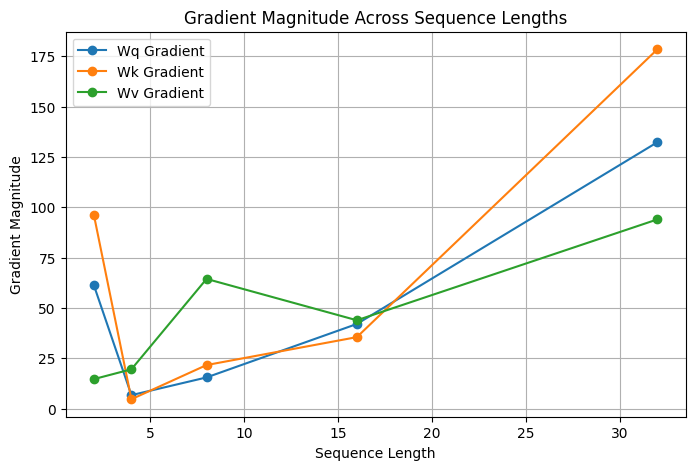

In [16]:
# Plot gradient magnitudes
plt.figure(figsize=(8, 5))

plt.plot(
    sequence_lengths,
    q_gradients,
    marker="o",
    label="Wq Gradient"
)

plt.plot(
    sequence_lengths,
    k_gradients,
    marker="o",
    label="Wk Gradient"
)

plt.plot(
    sequence_lengths,
    v_gradients,
    marker="o",
    label="Wv Gradient"
)

plt.xlabel("Sequence Length")
plt.ylabel("Gradient Magnitude")

plt.title(
    "Gradient Magnitude Across Sequence Lengths"
)

plt.legend()
plt.grid()

plt.show()

#Conclusion

A custom backward pass for a single-head self-attention layer was implemented without using Autograd. The gradients of the Query, Key, and Value projection matrices (Wq, Wk, Wv) were manually calculated using the chain rule. Gradient magnitudes were then tracked across different sequence lengths and visualized using a graph. This follows the Task 5 requirement for manual gradient calculation and gradient tracking.